<a href="https://colab.research.google.com/github/99735094/Controle-de--gastos/blob/main/Eu_mnist2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import do dataset

In [ ]:
from tensorflow.keras.datasets import mnist

# Divisão treinamento e testes

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
X_test.shape

(10000, 28, 28)

# Vendo uma imagem

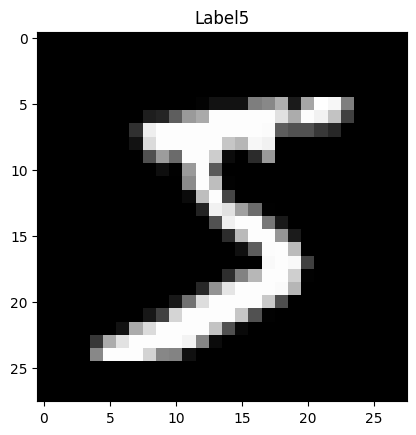

In [ ]:
import matplotlib.pyplot as plt

IDX=0
plt.imshow(X_train[IDX], cmap='gray')
plt.title("Label" + str(y_train[IDX]))
plt.show()

# Normalização

In [ ]:
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255


# Modelo

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
model = Sequential([
                    Flatten(input_shape=(28, 28)),
                    Dense(400, activation='relu'),
                    Dense(10, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 400)                 │         314,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           4,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 318,010 (1.21 MB)

 Trainable params: 318,010 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

# Compilação

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )

# Treinamento

In [ ]:
hist = model.fit(X_train,
          y_train,
          validation_data=(X_test, y_test),
          epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8968 - loss: 0.3567 - val_accuracy: 0.9693 - val_loss: 0.0994
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9747 - loss: 0.0861 - val_accuracy: 0.9757 - val_loss: 0.0783
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9833 - loss: 0.0529 - val_accuracy: 0.9795 - val_loss: 0.0702
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9884 - loss: 0.0380 - val_accuracy: 0.9785 - val_loss: 0.0711
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9914 - loss: 0.0272 - val_accuracy: 0.9791 - val_loss: 0.0716
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9942 - loss: 0.0186 - val_accuracy: 0.9812 - val_loss: 0.0667
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9946 - loss: 0.0161 - val_accuracy: 0.9797 - val_loss: 0.0713
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9964 - loss: 0

# Visualizando validação

<Axes: >

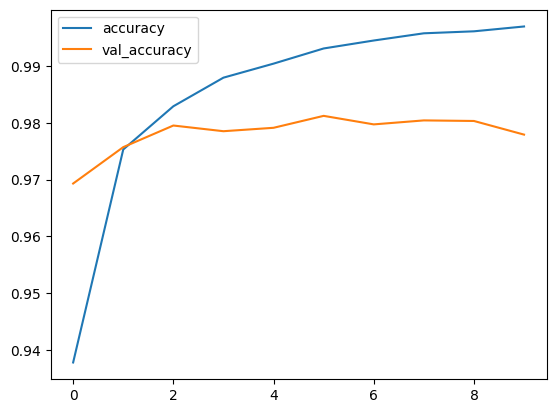

In [ ]:
import pandas as pd
df=pd.DataFrame(hist.history)
df[['accuracy', 'val_accuracy']].plot()

<Axes: >

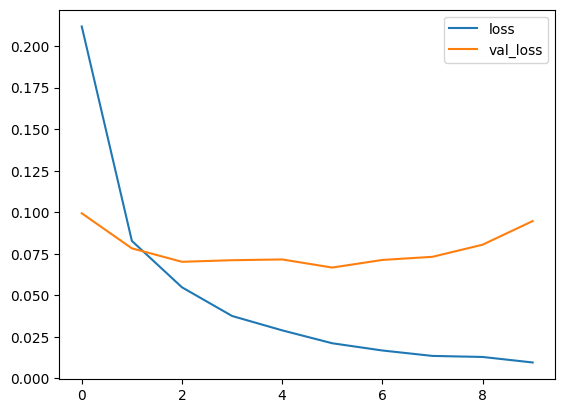

In [ ]:
df[['loss', 'val_loss']].plot()

# Salvando

In [ ]:
model.save('best_model.h5')

# Predição

In [ ]:
x=X_test[0].reshape(1, 28, 28, 1)

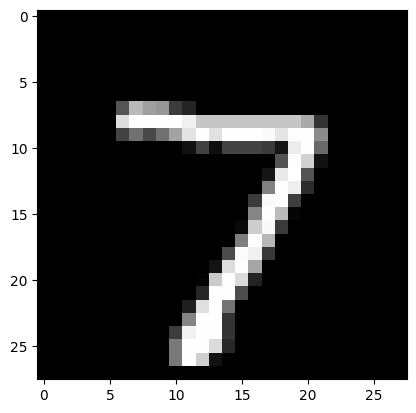

In [ ]:
plt.imshow(x.reshape(28, 28), cmap='gray')

In [ ]:
pred = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


In [ ]:
pred

array([[1.3597344e-09, 2.9515005e-13, 2.5864808e-10, 7.9493179e-07,
        3.9633006e-17, 7.7423304e-11, 4.1305433e-18, 9.9999917e-01,
        2.9407428e-11, 5.0188436e-09]], dtype=float32)

In [ ]:
idx = pred.argmax()
idx

7